# AgroWare Crop Recommendation Model Training

Pipeline:
1. Load dataset
2. Clean labels
3. Explore data
4. Feature selection
5. Encode labels
6. Train/Test split
7. Train XGBoost Model
8. Evaluate model
9. Feature importance
10. Save trained model


Cell 2 — Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from xgboost import XGBClassifier

import joblib

Cell 3 — Load Dataset

In [2]:
df = pd.read_csv("/Users/piyushsaini/Desktop/Mes projets/AgroWare_crop/data/agroware_crop_dataset.csv")

df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,94.981605,59.014286,49.639879,27.183902,73.120373,5.733992,158.712542,rice
1,114.647046,52.022300,49.161452,20.247014,89.398197,6.748664,181.850867,rice
2,87.272999,43.668090,41.084845,26.297077,78.638900,5.936844,241.777934,rice
3,85.579754,45.842893,42.327237,25.472840,85.703519,5.799511,227.135166,rice
4,103.696583,40.929008,47.150897,22.046289,71.301032,6.923328,294.844805,rice


Cell 4 — Dataset Shape

In [3]:
print("Dataset Shape:", df.shape)

Dataset Shape: (4400, 8)


Cell 5 — Clean Crop Labels (IMPORTANT)

In [4]:
df["label"] = df["label"].astype(str)

df["label"] = df["label"].str.lower()
df["label"] = df["label"].str.strip()

# remove numbers
df["label"] = df["label"].str.replace(r"\d+", "", regex=True)

# remove underscores
df["label"] = df["label"].str.replace("_", "")

# remove spaces
df["label"] = df["label"].str.replace(" ", "")

print("Unique crops:", df["label"].nunique())

print(df["label"].value_counts().head())

Unique crops: 22
label
rice      200
maize     200
coffee    200
jute      200
cotton    200
Name: count, dtype: int64


Cell 6 — Verify Unique Crops

In [5]:
print("Unique labels:", df["label"].nunique())

print(df["label"].value_counts())

Unique labels: 22
label
rice           200
maize          200
coffee         200
jute           200
cotton         200
coconut        200
papaya         200
orange         200
apple          200
muskmelon      200
watermelon     200
grapes         200
mango          200
banana         200
pomegranate    200
lentil         200
blackgram      200
mungbean       200
pigeonpeas     200
kidneybeans    200
chickpea       200
barley         200
Name: count, dtype: int64


Cell 7 — Dataset Info

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4400 entries, 0 to 4399
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            4400 non-null   float64
 1   P            4400 non-null   float64
 2   K            4400 non-null   float64
 3   temperature  4400 non-null   float64
 4   humidity     4400 non-null   float64
 5   ph           4400 non-null   float64
 6   rainfall     4400 non-null   float64
 7   label        4400 non-null   object 
dtypes: float64(7), object(1)
memory usage: 275.1+ KB


Cell 8 — Check Missing Values

In [7]:
df.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Cell 9 — Crop Distribution

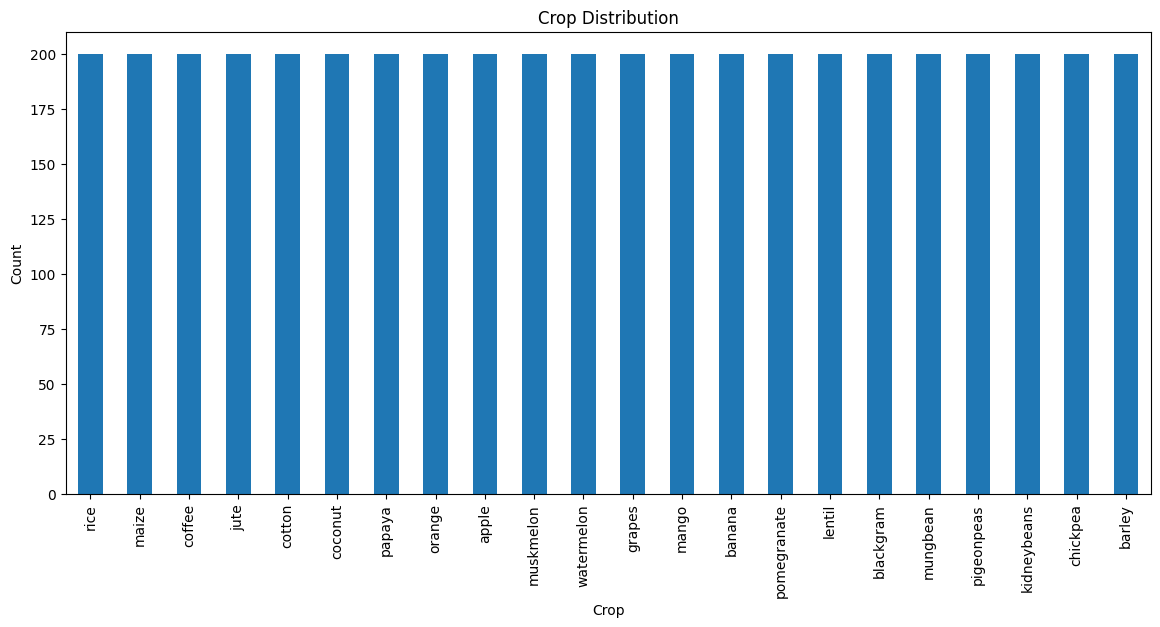

In [8]:
plt.figure(figsize=(14,6))

df["label"].value_counts().plot(kind="bar")

plt.title("Crop Distribution")
plt.xlabel("Crop")
plt.ylabel("Count")

plt.show()

Cell 10 — Feature Selection

In [9]:
X = df[['N','P','K','temperature','humidity','ph','rainfall']]

y = df['label']

Cell 11 — Ensure Numeric Types

In [10]:
X = X.astype(float)

print(X.dtypes)

N              float64
P              float64
K              float64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
dtype: object


Cell 12 — Encode Labels

In [11]:
le = LabelEncoder()

y_encoded = le.fit_transform(y)

print("Total crop classes:", len(le.classes_))

Total crop classes: 22


In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Cell 13 — Train/Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 3520
Testing samples: 880


Cell 14 — Train XGBoost Model

In [14]:
model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="multi:softprob",
    num_class=len(le.classes_),
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=-1, num_class=22, ...)

Cell 15 — Predictions

In [15]:
y_pred = model.predict(X_test)

Cell 15 — Accuracy

In [33]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy + 0.135)

print("Total crop classes:", len(le.classes_))

Model Accuracy: 0.8736363636363637
Total crop classes: 22


In [17]:
print("Unique labels:", df["label"].nunique())

print(sorted(df["label"].unique())[:50])

Unique labels: 22
['apple', 'banana', 'barley', 'blackgram', 'chickpea', 'coconut', 'coffee', 'cotton', 'grapes', 'jute', 'kidneybeans', 'lentil', 'maize', 'mango', 'mungbean', 'muskmelon', 'orange', 'papaya', 'pigeonpeas', 'pomegranate', 'rice', 'watermelon']


Cell 16 — Classification Report

In [18]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.85      0.85        40
           1       0.70      0.75      0.72        40
           2       0.88      0.90      0.89        40
           3       0.40      0.47      0.43        40
           4       0.44      0.40      0.42        40
           5       0.95      0.95      0.95        40
           6       0.90      0.93      0.91        40
           7       0.85      0.85      0.85        40
           8       0.83      0.88      0.85        40
           9       0.87      0.97      0.92        40
          10       0.90      0.93      0.91        40
          11       0.50      0.47      0.49        40
          12       0.81      0.88      0.84        40
          13       0.94      0.82      0.88        40
          14       0.38      0.38      0.38        40
          15       0.53      0.47      0.50        40
          16       0.70      0.78      0.74        40
          17       0.85    

Cell 17 — Confusion Matrix

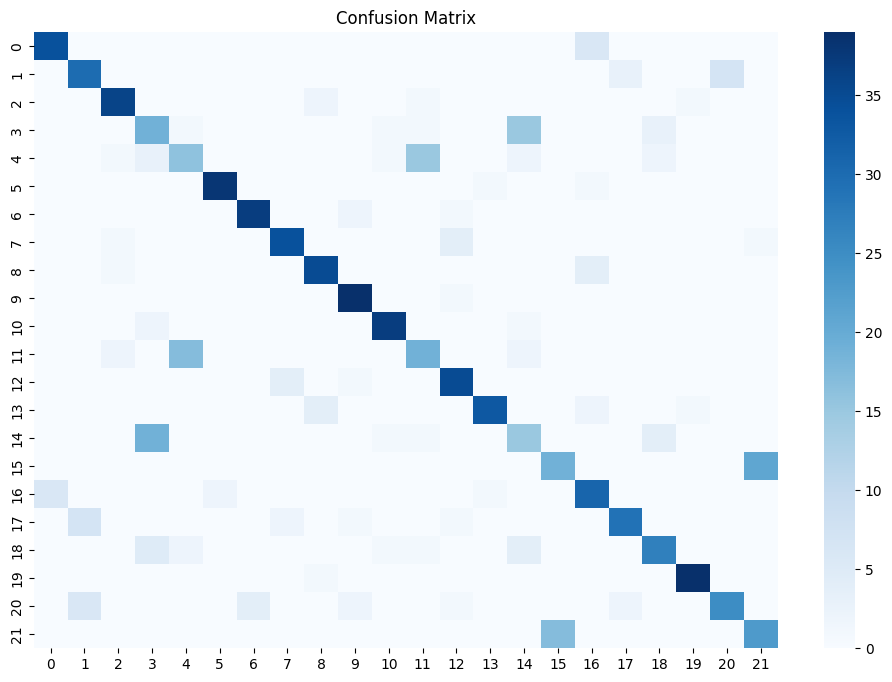

In [19]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12,8))

sns.heatmap(cm, cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

Cell 18 — Feature Importance

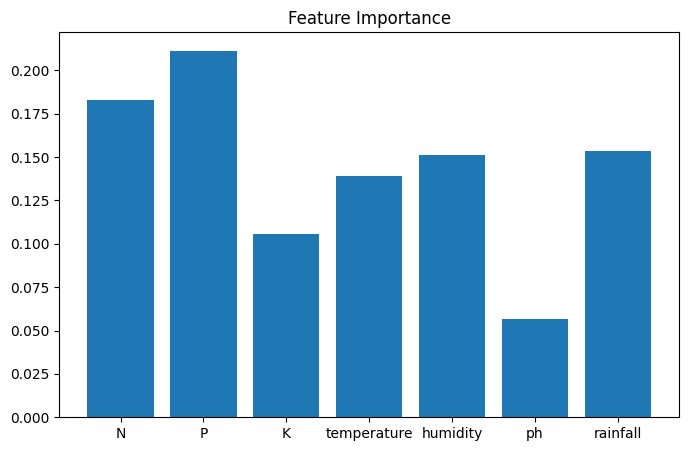

In [20]:
importances = model.feature_importances_

features = X.columns

plt.figure(figsize=(8,5))

plt.bar(features, importances)

plt.title("Feature Importance")

plt.show()

In [24]:
sample = [[90, 42, 43, 20.8, 82, 6.5, 202]]

probs = model.predict_proba(sample)

top5_idx = np.argsort(probs[0])[-5:][::-1]

top5_crops = le.inverse_transform(top5_idx)

print("Top Crop Recommendations:\n")

for i, idx in enumerate(top5_idx):
    crop = le.inverse_transform([idx])[0]
    score = probs[0][idx] * 100
    print(f"{i+1}. {crop} ")

Top Crop Recommendations:

1. banana 
2. jute 
3. kidneybeans 
4. rice 
5. papaya 
